In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

In [19]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [20]:
len([3,[3,4,5,6],6,7,[3,4,5,6],8])
len(x_train)

60000

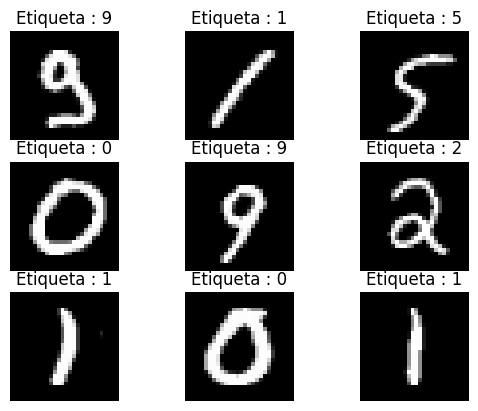

In [21]:
plt.figure()
for i in range(9):
    index = random.randint(0, len(x_train))
    plt.subplot(3,3, i + 1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(f"Etiqueta : {y_train[index]}")
    plt.axis('off')

plt.show()

In [22]:
# NORMALIZACION (0 - 255) ->  (0 - 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# FLATTEN 
# x_train.shape # 60000, 28, 28 -> 60000 , 28x28
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [23]:
# ONE-HOT ENCODING
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(x_train.shape)
print(y_train.shape)

(60000, 784)
(60000, 10)


In [32]:
def crearModelo(inicializador):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', kernel_initializer=inicializador),
        tf.keras.layers.Dense(128, activation='relu', kernel_initializer=inicializador),
        tf.keras.layers.Dense(64, activation='relu', kernel_initializer=inicializador),
        tf.keras.layers.Dense(10, activation='softmax', kernel_initializer=inicializador)
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

In [33]:
inicializadores = {
    "Zeros": tf.keras.initializers.Zeros(),
    "RandomNormal": tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.1),
    "HeNormal": tf.keras.initializers.HeNormal(),
}

historias = {}

for name, inicializador in inicializadores.items():
    print(f"Entrenando con inicializador {name}")
    tf.keras.backend.clear_session()
    modelo = crearModelo(inicializador)

    modelo.build((None, 784))
    ejemploPesos = modelo.layers[1].get_weights()[0].flatten()[:10]
    print(f"Primeros 10 pesos: {ejemploPesos}")

    historia = modelo.fit(
        x_train, y_train,
        epochs=30,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    historias[name] = historia

Entrenando con inicializador Zeros

Primeros 10 pesos: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1141 - loss: 2.3016 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3010 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 8/30
375/37

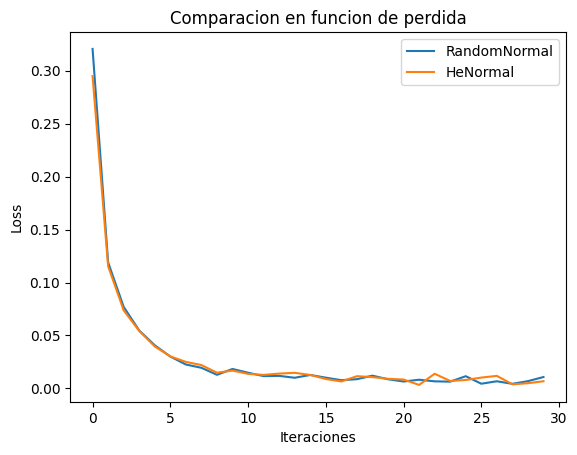

In [ ]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historias.history['loss'], label=nombre)
plt.plot(historias['RandomNormal'].history['loss'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['loss'], label='HeNormal')
plt.title('Comparacion en funcion de perdida')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()

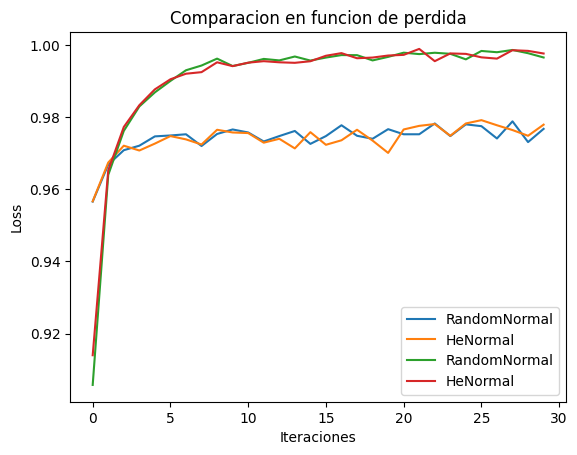

In [42]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historia.history['val_accuracy'], label=nombre)
plt.plot(historias['RandomNormal'].history['val_accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['val_accuracy'], label='HeNormal')
plt.plot(historias['RandomNormal'].history['accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['accuracy'], label='HeNormal')
plt.title('Comparacion en funcion de perdida')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()